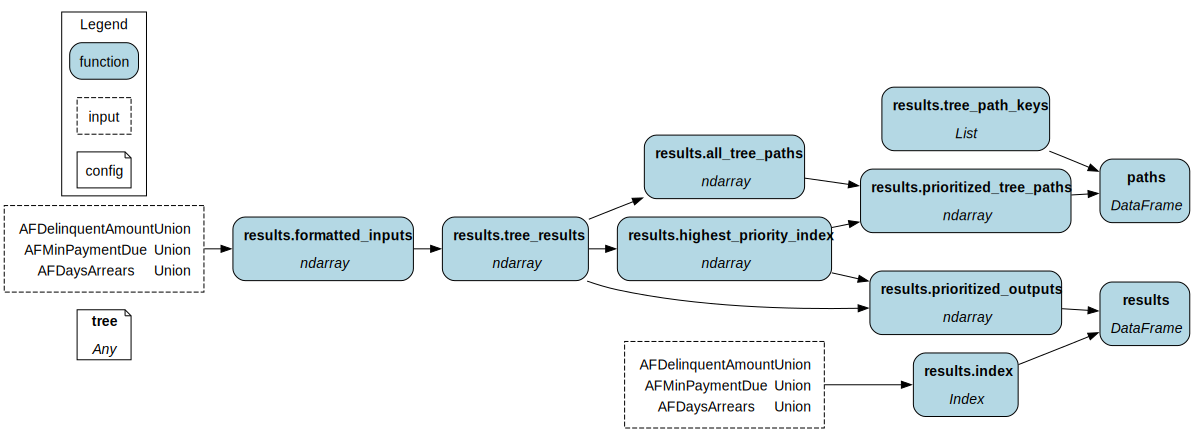

In [7]:
from spockflow.inference import handler
import pandas as pd
import os
import json
import requests

os.environ["MODEL_PREFIX"] = os.path.abspath(".")
os.environ["MODEL_RELATIVE_PATH"] = "source_dir"
h = handler.ServingHandler.from_model_project()
model = h.model_cache.get(None, None)
model

In [8]:
with open("data.json") as fp:
    input_data = pd.json_normalize(json.load(fp))
input_data

,AFDelinquentAmount,AFDaysArrears,AFMinPaymentDue
0,-60,-1,0
1,100,-1,0
2,-60,1,0
3,100,1,0
4,-60,-1,1
5,100,-1,1
6,-60,1,1
7,100,1,1


In [9]:
combined_res = model.execute(
    inputs=input_data, 
)
combined_res

,paths.99f9bc9c-a510-401a-96d4-f1d137e1e81e,paths.7ad858d9-2df8-4a03-84cc-dda84d8bcc41,paths.12f56432-7524-40df-aa93-84d23dfc26b0,results.Result
0,-1,0,0,Negative
1,1,-1,0,Negative
2,-1,0,0,Negative
3,1,1,-1,Negative
4,-1,0,0,Negative
5,1,-1,0,Negative
6,-1,0,0,Negative
7,1,1,1,Positive


In [10]:
res_everything = model.raw_execute(
    inputs=input_data, 
    final_vars=list(model.graph.nodes.keys())
)
res_everything

{'paths':    99f9bc9c-a510-401a-96d4-f1d137e1e81e  7ad858d9-2df8-4a03-84cc-dda84d8bcc41  \
 0                                    -1                                     0   
 1                                     1                                    -1   
 2                                    -1                                     0   
 3                                     1                                     1   
 4                                    -1                                     0   
 5                                     1                                    -1   
 6                                    -1                                     0   
 7                                     1                                     1   
 
    12f56432-7524-40df-aa93-84d23dfc26b0  
 0                                     0  
 1                                     0  
 2                                     0  
 3                                    -1  
 4                                  

In [12]:
resp = requests.post(
    "http://localhost:8000/invocations",
    data = input_data.to_json(orient="records").encode() ,
    headers={"accept": "*/*", "Content-Type": "application/json"}
)
resjson = resp.json()
resjson

[{'Result': 'Negative',
  '99f9bc9c-a510-401a-96d4-f1d137e1e81e': -1,
  '7ad858d9-2df8-4a03-84cc-dda84d8bcc41': 0,
  '12f56432-7524-40df-aa93-84d23dfc26b0': 0},
 {'Result': 'Negative',
  '99f9bc9c-a510-401a-96d4-f1d137e1e81e': 1,
  '7ad858d9-2df8-4a03-84cc-dda84d8bcc41': -1,
  '12f56432-7524-40df-aa93-84d23dfc26b0': 0},
 {'Result': 'Negative',
  '99f9bc9c-a510-401a-96d4-f1d137e1e81e': -1,
  '7ad858d9-2df8-4a03-84cc-dda84d8bcc41': 0,
  '12f56432-7524-40df-aa93-84d23dfc26b0': 0},
 {'Result': 'Negative',
  '99f9bc9c-a510-401a-96d4-f1d137e1e81e': 1,
  '7ad858d9-2df8-4a03-84cc-dda84d8bcc41': 1,
  '12f56432-7524-40df-aa93-84d23dfc26b0': -1},
 {'Result': 'Negative',
  '99f9bc9c-a510-401a-96d4-f1d137e1e81e': -1,
  '7ad858d9-2df8-4a03-84cc-dda84d8bcc41': 0,
  '12f56432-7524-40df-aa93-84d23dfc26b0': 0},
 {'Result': 'Negative',
  '99f9bc9c-a510-401a-96d4-f1d137e1e81e': 1,
  '7ad858d9-2df8-4a03-84cc-dda84d8bcc41': -1,
  '12f56432-7524-40df-aa93-84d23dfc26b0': 0},
 {'Result': 'Negative',
  '99f9bc9